# Frozen Lake con Q-Learning y Gymnasium

En esta sección utilizaremos la librería estándar de la industria `gymnasium` para resolver el entorno de Frozen Lake utilizando Reinforcement Learning (Q-Learning).

## Task 2.1 - Inicialización y Exploración
Instalaremos gymnasium y configuraremos el entorno estocástico (`is_slippery=True`).

In [ ]:
# Instalamos gymnasium si no está en el sistema. Usamos %pip para instalar en el kernel actual.
%pip install gymnasium pygame

import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time

In [3]:
# Inicializar el entorno
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True, render_mode="rgb_array")

# Exploración de espacios de estados y acciones
n_states = env.observation_space.n
n_actions = env.action_space.n

print(f"Espacio de Estados (Discrete): {n_states}")
print(f"Espacio de Acciones (Discrete): {n_actions}")

Espacio de Estados (Discrete): 16
Espacio de Acciones (Discrete): 4


## Task 2.2 - Algoritmo Q-Learning
Implementamos el algoritmo de Q-Learning con una política Epsilon-Greedy, aplicando un decaimiento gradual del epsilon.

In [4]:
# 1. Inicializar la tabla Q con ceros
q_table = np.zeros((n_states, n_actions))

# 2.a. Definir hiperparámetros
alpha = 0.8          # Learning Rate
gamma = 0.95         # Factor de Descuento
n_episodes = 10000   # Número de episodios

# Parámetros para Epsilon-Greedy
epsilon = 1.0        # Epsilon inicial (100% exploración)
max_epsilon = 1.0    
min_epsilon = 0.01   # Mínima probabilidad de exploración
decay_rate = 0.001   # Tasa de decaimiento (decay rate)

rewards_all_episodes = []

# 2.b. Bucle de Entrenamiento
for episode in range(n_episodes):
    # i.1. Resetear el entorno
    state, info = env.reset()
    done = False
    truncated = False
    rewards_current_episode = 0
    
    # i.2. Mientras no termine el juego
    while not (done or truncated):
        # a. Elegir acción (Epsilon-Greedy)
        exploration_rate_threshold = random.uniform(0, 1)
        if exploration_rate_threshold > epsilon:
            # Explotación de la Tabla Q
            action = np.argmax(q_table[state, :])
        else:
            # Exploración aleatoria
            action = env.action_space.sample()
            
        # b. Ejecutar acción y observar nuevo estado y recompensa
        new_state, reward, done, truncated, info = env.step(action)
        
        # c. Actualizar Q(s,a): Q(s,a) = Q(s,a) + alpha * [R + gamma * maxQ(s',a') - Q(s,a)]
        q_table[state, action] = q_table[state, action] + alpha * \
            (reward + gamma * np.max(q_table[new_state, :]) - q_table[state, action])
            
        # d. Actualizar estado actual
        state = new_state
        rewards_current_episode += reward
        
    # Reducimos epsilon gradualmente para explorar menos al avanzar (decay)
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    rewards_all_episodes.append(rewards_current_episode)

print(f"Entrenamiento completado después de {n_episodes} episodios.")
print("Tabla Q Final:")
print(q_table)

Entrenamiento completado después de 10000 episodios.
Tabla Q Final:
[[2.63558640e-01 2.46286761e-02 4.61604653e-02 1.85331604e-01]
 [7.89142138e-06 1.09130681e-02 4.72908776e-03 2.39712163e-01]
 [1.48586155e-02 1.04525515e-02 9.53323711e-03 1.28312931e-01]
 [2.65062162e-03 4.56710144e-04 1.86192864e-05 4.82856662e-02]
 [5.75435659e-01 8.10212289e-03 1.85991236e-01 3.74818291e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [4.36470332e-05 2.59143705e-05 3.75237281e-02 2.82857722e-09]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.37357977e-02 1.26718720e-02 2.36711196e-02 3.87323294e-01]
 [2.21370704e-04 7.27894429e-01 7.59050195e-03 7.01790755e-03]
 [2.34254380e-03 1.98466360e-04 9.15436873e-03 3.00351590e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.11706546e-01 6.01909852e-02 9.23801163e-01 8.22005636e-02]
 [7.56829204e-02 5.96351450e-01 2.24158140e-01 2.1

## Task 2.3 - Prueba y Evaluación
Evaluamos la política aprendida (puramente codiciosa, $\epsilon=0$) en 10 episodios y calculamos el Win Rate. Luego visualizamos uno de los éxitos.

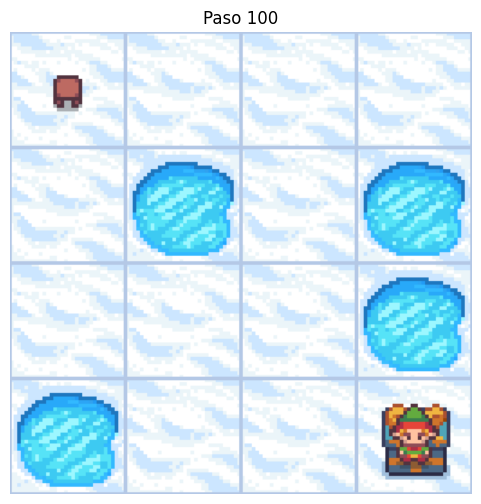

In [5]:
# Ejecutar 10 episodios de prueba (sin exploración, epsilon = 0)
test_episodes = 10
wins = 0

successful_episode_frames = [] # Guardaremos las imágenes si encontramos un éxito para renderizarlo
found_success = False

for ep in range(test_episodes):
    state, info = env.reset()
    done = False
    truncated = False
    ep_frames = []
    
    if not found_success:
        ep_frames.append(env.render())
        
    while not (done or truncated):
        # Acción puramente codiciosa
        action = np.argmax(q_table[state, :])
        state, reward, done, truncated, info = env.step(action)
        
        if not found_success:
            ep_frames.append(env.render())
            
        if done and reward == 1.0:
            wins += 1
            # Si llegamos a la meta por primera vez, guardamos los frames
            if not found_success:
                successful_episode_frames = ep_frames
                found_success = True

# Calcular y reportar Win Rate
win_rate = (wins / test_episodes) * 100
print(f"\nResultados de {test_episodes} episodios de prueba:")
print(f"Win Rate: {win_rate}%")

# Visualizar un episodio exitoso
if found_success:
    print("\nReproduciendo un episodio exitoso...")
    fig, ax = plt.subplots(figsize=(6, 6))
    for i, frame in enumerate(successful_episode_frames):
        ax.clear()
        ax.imshow(frame)
        ax.axis('off')
        ax.set_title(f"Paso {i}")
        display(fig)
        clear_output(wait=True)
        time.sleep(0.3) # Pausa para crear el efecto de animación
else:
    print("\nLamentablemente, el agente no logró llegar a la meta en ninguno de estos episodios de prueba.")